In [1]:
import numpy as np
import scipy
import scipy.special
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt
from IPython.display import display
import threading
from io import StringIO 
import sys
import ipywidgets as widgets
import math
import os


import plotly
import plotly.graph_objs as go


import diffractsim
diffractsim.set_backend("CPU")
from diffractsim import nm, mm, cm, um

from PIL import Image

Let's reproduce the OAM mode sorter posited by Robert Fickler et al. 

# Implementation using Functions

In [2]:
# Fresnel Propagator Function

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))

    
    return u2 


'''
This function implements the Fraufoner Diffraction Transfer Approach instead. Translation from Voelz
u1 - source field
L1 - full observation side length 
la - wavelength 
z - prop distance


returns: 
u2 - observation field at z
L2 - observation field side lengths
'''

def propFF(u1, L1, la, z, isInverse = False):
    #Some initial calcs from the source field
    
    M, nn = np.shape(u1)
    dx1 = L1/M
    k = 2*np.pi/la
    
    # compute params for observation plane
    
    L2 = (la*z)/dx1
    dx2 = (la*z)/L1
    
    # compute field at observation plane 
    x2 = np.arange(-L2/2,L2/2,dx2)
    
    xx2, yy2 = np.meshgrid(x2, x2)
    
    # Fraufofner transfer function? 

    c = (1/(1j*la*z))*np.exp(1j*(k/2*z)*(xx2**2 + yy2**2))
    
    if(isInverse):
        u2 = c*fftshift(ifft2(ifftshift(u1)))*dx1**2
        
    else:
        u2 = c*ifftshift(fft2(fftshift(u1)))*dx1**2
    
    return u2, L2



# LG modes 

'''
# Generates the normalized LG field.
# Expression adapted from Saleh. The normalization factor is adapted from wikipedia, 
# then modified silghtly so that the LG mode expression in wikipedia and Saleh are equivalent
#
# RHO, PHI - polar coordinate field
# ell - azimuthal index
# p - radial index
# w0 - beam waist (in units of ... w0)
# h - grid step size
# z - propagation distance
# k - wavenumber
'''

def LG(RHO,PHI,ell,p,w0,h,z,k):
    wL = (2*np.pi)/(k)
    z_o = np.pi*w0**2/wL
    w_z = lambda z: w0*np.sqrt(1 + (z/z_o)**2)
    R_z = lambda z: z*(1+(z_o/z)**2)
    zeta_z = lambda z: np.arctan(z/z_o)

    N_factor = 1
    if (z == 0):
        AK = N_factor * np.exp(-(RHO/w0)**2) * ((RHO/w0)**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w0)**2) * np.exp(1j * ell * phi))
    else:
        AK = N_factor * (w0/w_z(z)) * np.exp(-(RHO/w_z(z))**2) * ((RHO/w_z(z))**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w_z(z))**2) * np.exp(1j * ell * phi))*np.exp(-1j*k*z) * np.exp(-1j*k*(RHO**2/(2*R_z(z)))) * np.exp(1j*(abs(ell)+2*p + 1)*zeta_z(z))
    reNormFactor = np.sqrt(np.sum(np.conj(AK)*AK * h**2)) # We use this to further normalize the field with respect to 
    return  AK/reNormFactor

'''
Generates knots
# This function intialises the knot field that we want to generate.
# rr, phi - field coordinates
# w0 - input beam waist (in mm)
# knotType - string - selects the polynomial characteristic of the knot
# shapeParams - float list - list of knot parameters (a,b,kk) expected
'''

def setKnotType(rr, phi, w0,  knotType, shapeParams): 
    
    rs = rr/w0 # dimensionless, scaled beam coordinate
    a,b,kk = shapeParams
    
    if (knotType == 'Trefoil'): # Input beam profile (Trefoil)
        AK=np.exp(-(rs/(np.sqrt(2)*kk))**2)*(1 - rs**2 - 4 * (a**2 - b**2) * rs**3 - rs**4 + rs**6 - 2 *(a - b)**2 * (rs*np.exp(-1j*phi))**3 - 2 *(a + b)**2 * (rs*np.exp(1j*phi))**3)
    
    if (knotType == 'Hopflink'): # Input beam profile (Hopf Link)
        AK = (1 - 2*(1+a**2 - b**2)*rs**2 + rs**4 - 2*(a**2 + b**2)*np.cos(2*phi)*rs**2 - 1j*4*a*b*np.sin(2*phi)*rs**2)*np.exp(-(rs/(np.sqrt(2)*kk))**2)

    if (knotType == 'Cinquefoil'): # Input beam profile (Cinquefoil)
        AK = np.exp(-(rs/(np.sqrt(2)*kk))**2) * (1 + rs**2 - 2*rs**4 - 16*(a**2 - b**2)*rs**5 - 2*rs**6 + rs**8 + rs**10 - (8*((a-b)**2)*(rs**5)*np.exp(-1j*5*(phi))) - (8*((a+b)**2)*(rs**5)*np.exp(1j*5*(phi))))
   
    return AK


# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()
    
    
'''
Cartesian to Polar coordinates 
x,y - x and y coordinates
'''

def cart2pol(x, y):
    rho = np.sqrt((x)**2 + (y)**2)
    phi = np.arctan2(y, x)
    return(rho, phi)



def lens_phase(rr,lens_rad, k, f): 
    t = 1
    pupil_func = (np.where(rr**2 < lens_rad**2,t, np.zeros_like(xx)))
    trans_func = pupil_func*np.exp(-1j*(2*k/f)*(r)**2)
    
    return pupil_func*np.exp(-1j*(2*k/f)*(r)**2)



# Pupil function which we convolve with the outgoing field 

def pupil_function(rr, lens_rad):
    t = 1
    return (np.where(rr**2 < lens_rad**2,t, np.zeros_like(rr)))
    

def random_phase(xx,yy):
    t = 1
    res = len(xx)
    
    x_min = random.uniform(0,1)
    x_max = x_min + random.uniform(0.5,1) # How much of the plate do we want to shine?
    y_min = random.uniform(0,1)
    y_max = y_min + random.uniform(0.5,1)
            
    x = np.linspace(x_min, x_max, res)
    y = np.linspace(y_min, y_max, res)

    X, Y = np.meshgrid(x, y)
    silt_func = generate_random_function(X, Y, -1, 1, 2, 3, math.radians(5))
    return np.exp(-1j*np.pi*silt_func)



Defining the coordinate space

In [3]:
# Define the coordinate space 

la = 0.5*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
maxx = 1.5 * mm # Full length of the numerical window (m)
N=128 # [Number of points per dimension]

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)
h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

print(X)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)

[-7.5000000e-04 -7.3828125e-04 -7.2656250e-04 -7.1484375e-04
 -7.0312500e-04 -6.9140625e-04 -6.7968750e-04 -6.6796875e-04
 -6.5625000e-04 -6.4453125e-04 -6.3281250e-04 -6.2109375e-04
 -6.0937500e-04 -5.9765625e-04 -5.8593750e-04 -5.7421875e-04
 -5.6250000e-04 -5.5078125e-04 -5.3906250e-04 -5.2734375e-04
 -5.1562500e-04 -5.0390625e-04 -4.9218750e-04 -4.8046875e-04
 -4.6875000e-04 -4.5703125e-04 -4.4531250e-04 -4.3359375e-04
 -4.2187500e-04 -4.1015625e-04 -3.9843750e-04 -3.8671875e-04
 -3.7500000e-04 -3.6328125e-04 -3.5156250e-04 -3.3984375e-04
 -3.2812500e-04 -3.1640625e-04 -3.0468750e-04 -2.9296875e-04
 -2.8125000e-04 -2.6953125e-04 -2.5781250e-04 -2.4609375e-04
 -2.3437500e-04 -2.2265625e-04 -2.1093750e-04 -1.9921875e-04
 -1.8750000e-04 -1.7578125e-04 -1.6406250e-04 -1.5234375e-04
 -1.4062500e-04 -1.2890625e-04 -1.1718750e-04 -1.0546875e-04
 -9.3750000e-05 -8.2031250e-05 -7.0312500e-05 -5.8593750e-05
 -4.6875000e-05 -3.5156250e-05 -2.3437500e-05 -1.1718750e-05
  0.0000000e+00  1.17187

Testing out the pupil function 

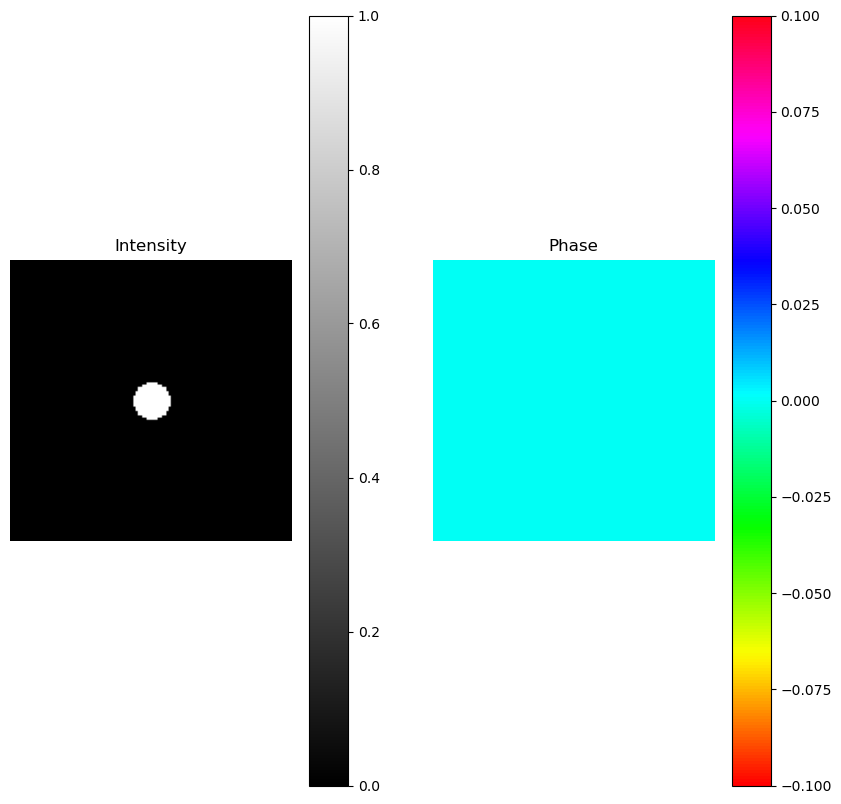

In [4]:
spotty = pupil_function(r, 0.1*mm)
TotInt(spotty)

Defining multiple spots

[-0.0012550393243553788, -0.0006986789194714362, -7.810361893662758e-05]


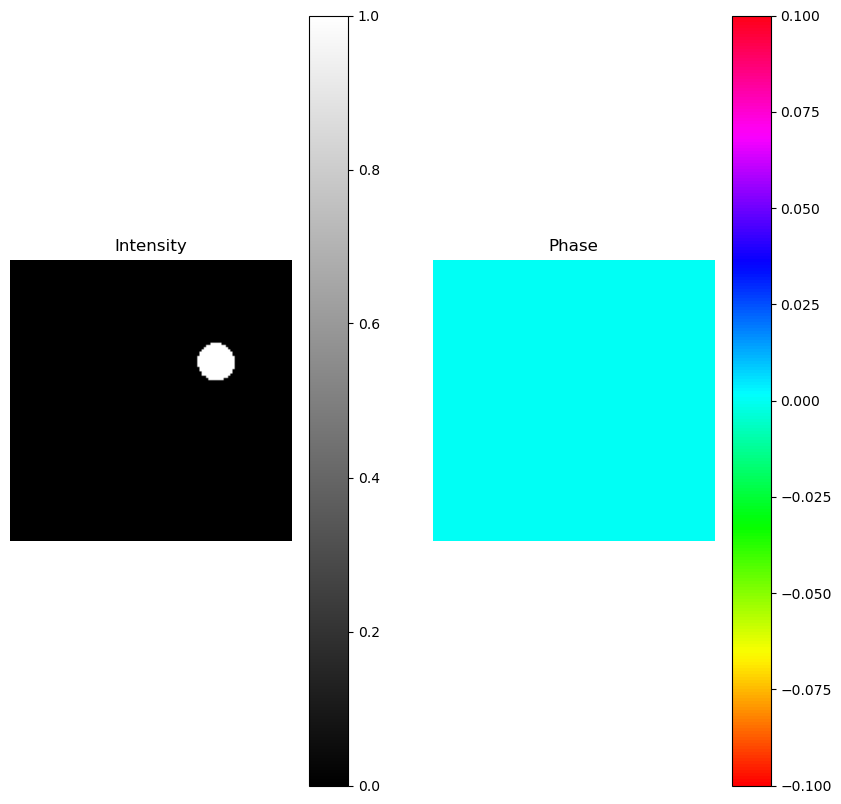

In [5]:
num_of_output_chans = 3

def output_chan(X, Y, rad_spot, maxx, num_of_spots):
    N = len(X)
    spot_loc_x = []
    spot_loc_y = []
    
    for ii in range(num_of_spots):
        spot_loc_x.append(np.random.uniform(-maxx+rad_spot,maxx-rad_spot))
        spot_loc_y.append(np.random.uniform(-maxx+rad_spot,maxx-rad_spot))
    
    print(spot_loc_x)
    
    fields = np.empty((num_of_spots, N, N), dtype=np.complex64)
    # Space definition 
    for ii in range(num_of_spots):
        X=np.linspace(-maxx,maxx,N) + spot_loc_x[ii]
        Y=np.linspace(-maxx,maxx,N) + spot_loc_y[ii]
        h=np.abs(X[1]-X[2]) # Step size
        xx,yy=np.meshgrid(X,Y)
        r, phi= cart2pol(xx,yy)
        
        fields[ii] = pupil_function(r, rad_spot)
    
    return fields, spot_loc_x, spot_loc_y # In principle, it suffices to return fields. 

output_chans, spot_loc_x, spot_loc_y = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)
TotInt(output_chans[1])

Generating the LG beam 

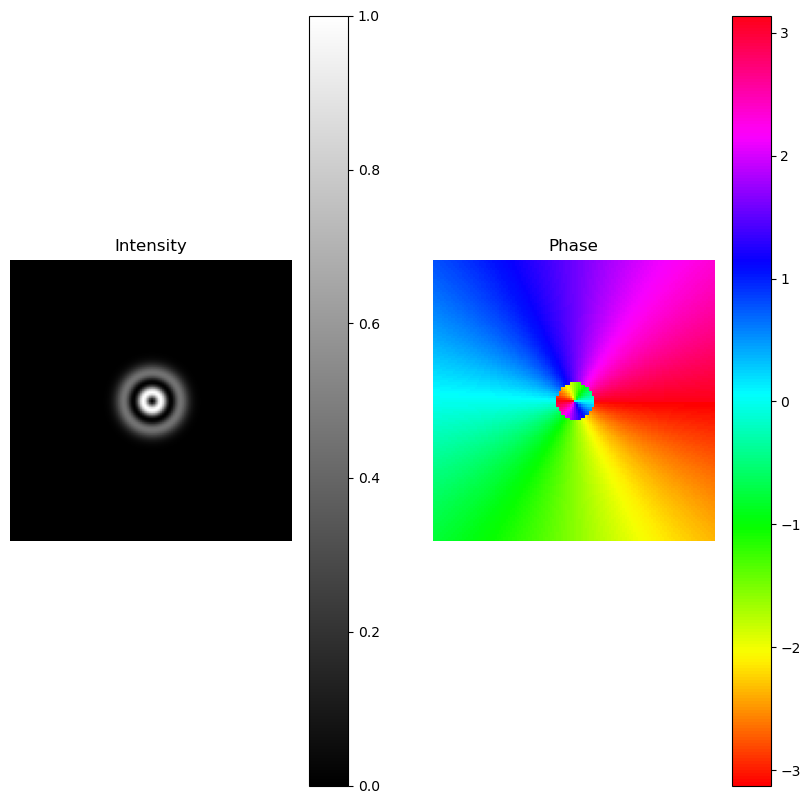

In [6]:
# Generating an LG mode as a test
field = LG(r, phi, 1, 1, 0.1*mm,h,0,k)
field = field / np.max(np.abs(field))
TotInt(field)

Let's get knotty

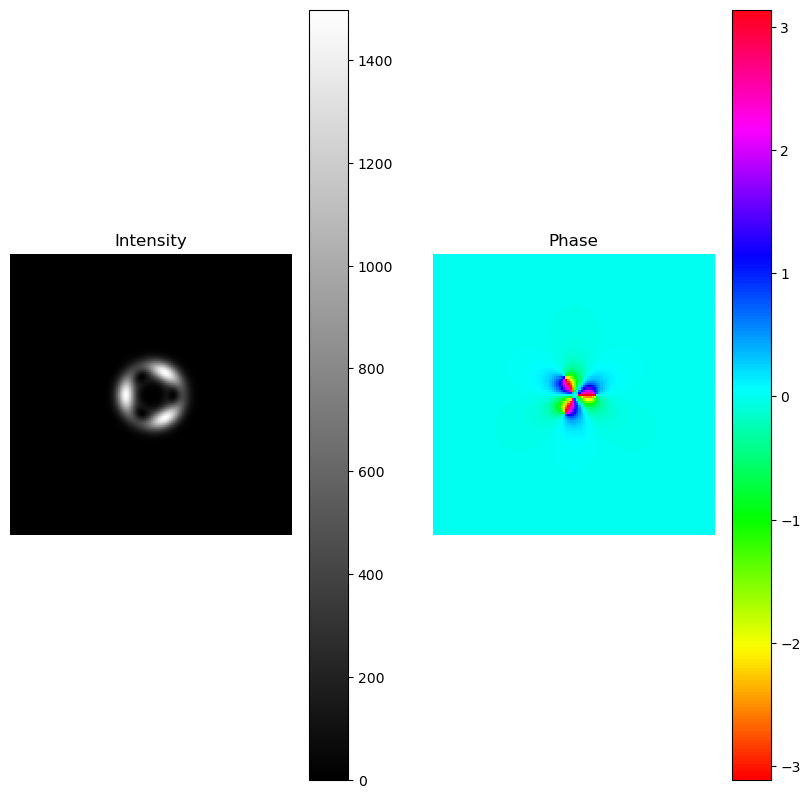

In [7]:
shapeParams = [1,1,1.2]
knotType = 'Trefoil'
w0 = 0.05*mm

# setKnotType(rr, phi, w0,  knotType, shapeParams)
field = setKnotType(r, phi, w0, knotType, shapeParams)
TotInt(field)

Now we propagate the beam towards the fourier length of the lens. Note that we are using Fraunhofer diffraction as we don't have to sample nearly as much. The solution of a beam propagating through a lens also comes out directly w/ z= the focal length of the lens. Here, we assume that the beam is in the back fourier plane. 

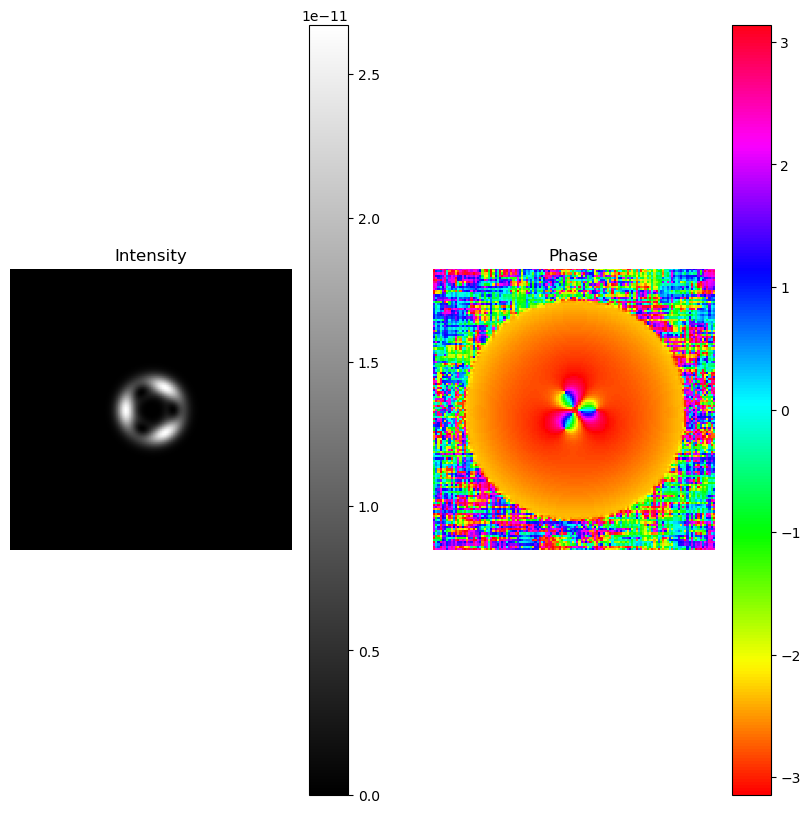

In [8]:
temp_1 = field
prop_dist = 10*cm

# Propagate the lens field to the focal plain of the lens

field_lens,_ = propFF(temp_1, maxx, la, prop_dist)

field_lens = field_lens/np.max(np.abs(field_lens))

# Propagate again immediately before the second lens

field_lens_2 = propFF(field_lens, maxx, la, prop_dist, isInverse=True)[0]

TotInt(field_lens_2)

To verify that what we see adds up, let's actually just compute the phase of the (inverse) fourier transform

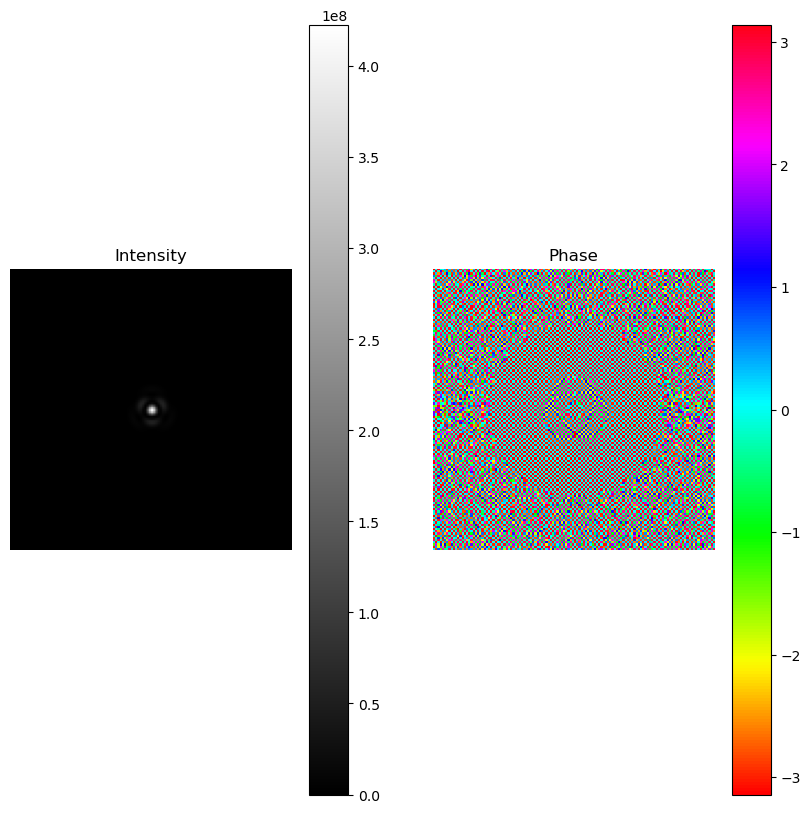

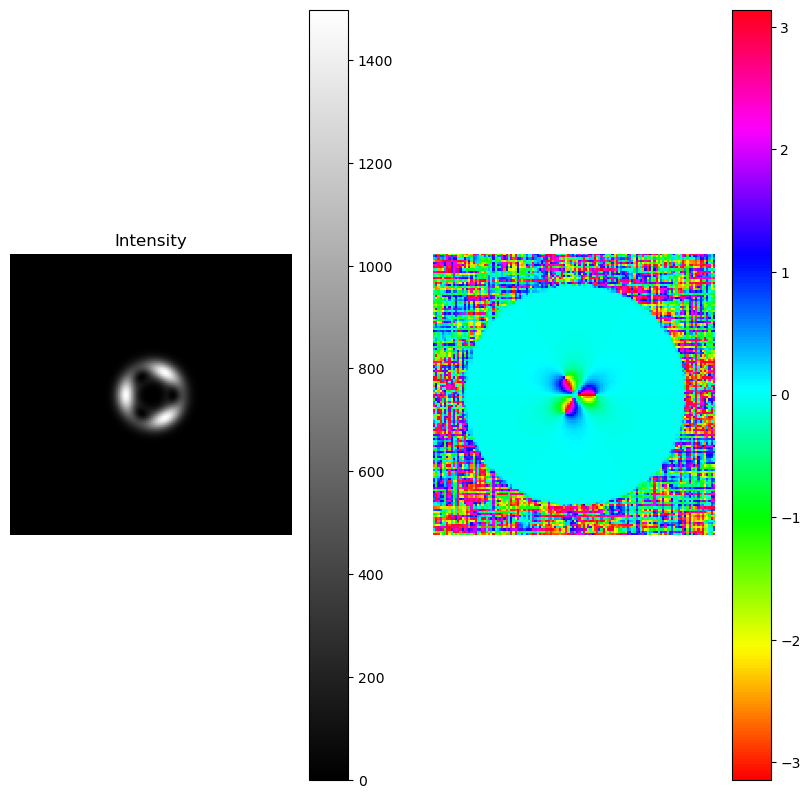

In [9]:
fourField = fftshift(fft2(temp_1))
invFourField = ifft2(ifftshift(fourField))
TotInt(fourField)
TotInt(invFourField)

# Computing the Sorting Probability

We'll need to define the fitness function, which is the sorting performance. For testing purposes, let's define a field having a gaussian beam at one of the three output_channels

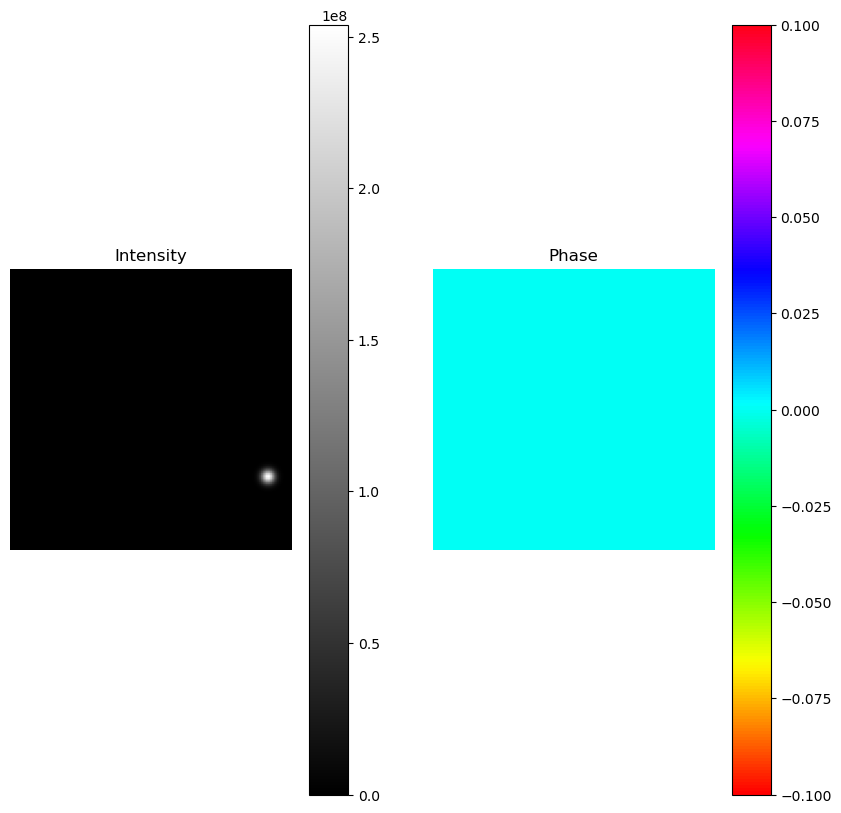

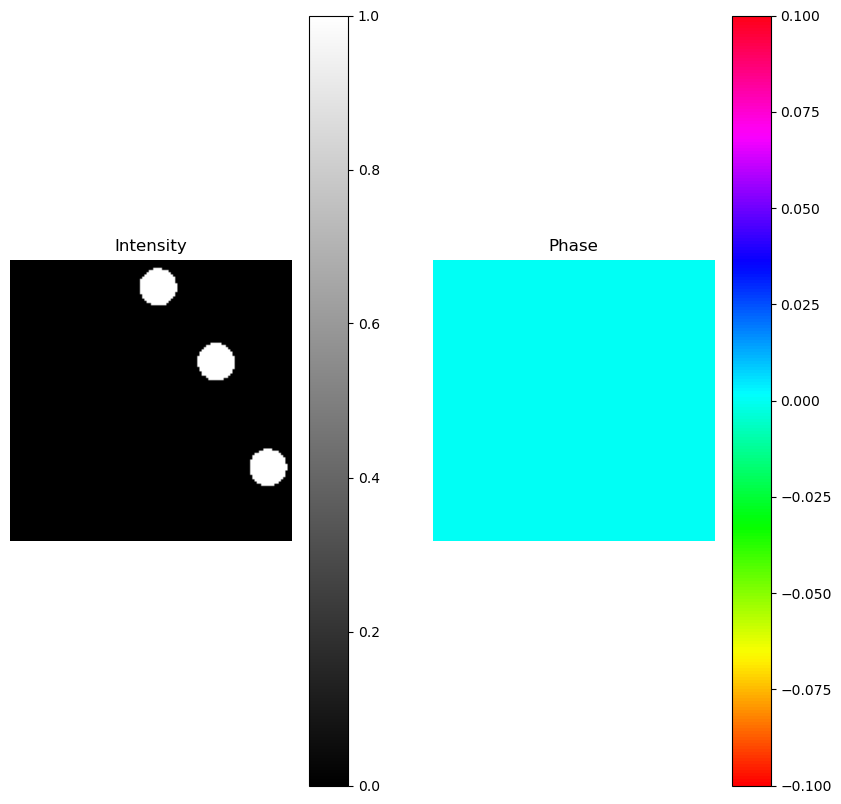

In [10]:
X_gauss=np.linspace(-maxx,maxx,N) + spot_loc_x[0]
Y_gauss=np.linspace(-maxx,maxx,N) + spot_loc_y[0]

h_gauss=np.abs(X[1]-X[2]) # Step size
xx_gauss,yy_gauss=np.meshgrid(X_gauss,Y_gauss)
r_gauss, phi_gauss= cart2pol(xx_gauss,yy_gauss)

# plotting the gaussian field 
gauss_field = LG(r_gauss, phi_gauss, 0, 0, 0.1*mm,h,0,k)
TotInt(gauss_field)
TotInt(np.sum(output_chans, axis=0))

We now compute the sorting performance. This can be done by taking the incident field and convolving it with the pupil array. 

In [11]:
# To normalize, we define the maximum sorting performance, which is the sum of intensities of each output channel

# max_output_intensity = np.sum(output_chans)

# plt.imshow(output_chans[0])

sorting_performance = 0 
ii = 0 # This defines mode n

# Define full set of indices, as you would summing through a for loop

full_index = np.arange(len(output_chans))   

# Delete ii from the list of full_index, creating a new temporary array
temp_index = np.delete(full_index, ii)
# Sum up the "incorrect" channels 
incorrect_chans = 0
for ind in temp_index:
    field_in_pupil = gauss_field*output_chans[ind]
    incorrect_chans += np.abs(field_in_pupil)**2
# Now, evaluate the sorting performance 
sorting_performance += np.abs(gauss_field*output_chans[ii])**2 - incorrect_chans 

# Genetic Algorithm

In [23]:
# Let's define a class that holds an OAM mode and its correponding output channel, defined from its centre

class oamModes():
    def __init__(self, oamBeam, output_chan_field):
        self.oamBeam = oamBeam 
        self.output_chan_field = output_chan_field

        

Create an array consisting of n OAM elements and m output channels

In [24]:
num_of_output_chans = 3
output_chans, spot_loc_x, spot_loc_y = output_chan(X,Y,0.1*mm,maxx,num_of_output_chans)

# Now create a list containing 'oamMode' objects 

list_of_OAMs = [oamModes(LG(r, phi, 1, 0, 0.2*mm,h,0,k), output_chans[0]), oamModes(LG(r, phi, -1, 0, 0.2*mm,h,0,k), output_chans[1])]

#field = LG(r, phi, 1, 0, 0.2*mm,h,0,k)
#TotInt(field)

[-0.00048791872816500654, -0.001027130025367576, -0.0005794732119317445]


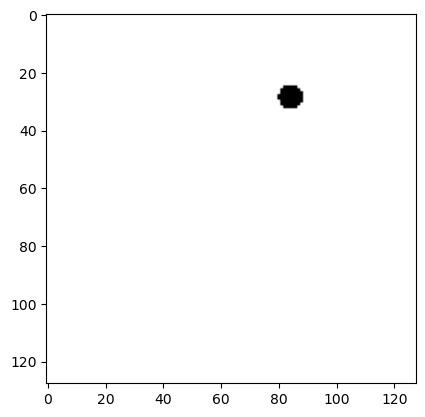

In [25]:
plt.imshow(np.abs(output_chans[0])**2, cmap = 'Greys')


We ... flatten them???

In [26]:
random_phase_modulation_1 = np.random.uniform(-np.pi, np.pi, size=(N,N))
random_phase_modulation_2 = np.random.uniform(-np.pi, np.pi, size=(N,N))

flattened_phase_1 = random_phase_modulation_1.flatten()
flattened_phase_2 = random_phase_modulation_2.flatten()


Define the fitness function. This will be the sorting performance function that we computed earlier

In [27]:
fourier_lens = 10*cm 

# Compute output channels

# num_of_output_chans = 2

# output_chans, _, _ = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)

def fitness_func(ga_instance, solution, solution_idx):

    # Create the phase map by reshaping the solution array

    reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
    reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
    phase_map_1 = np.exp(1j*reshape_phase_1)
    phase_map_2 = np.exp(1j*reshape_phase_2)
    
    # Now, this is the fitness parameter 

    sorting_performance = 0  

    for ii in range(len(list_of_OAMs)):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 

        # modulate the field by the first phase map 

        field_mod_1 = field*phase_map_1

        # let's simulate the propagation of the lens

        field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

        # modulate the field by the second phase map 

        field_mod_2 = field_lens*phase_map_2

        # simulate the lens field again. This is the final field. 

        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

        # compute the field intensity 

        final_field_int = np.abs(field_lens_2)**2

        # Define full set of indices, as you would summing through a for loop

        full_index = np.arange(len(output_chans))   

        # Delete ii from the list of full_index, creating a new temporary array

        temp_index = np.delete(full_index, ii)

        # Sum up the "incorrect" channels 

        incorrect_chans = 0

        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chans += np.abs(field_in_pupil)**2

        # Now, evaluate the sorting performance 

        correct_chans = np.abs(final_field_int*output_chans[ii])**2

        sorting_performance += correct_chans - incorrect_chans 

    return np.mean(sorting_performance)
    

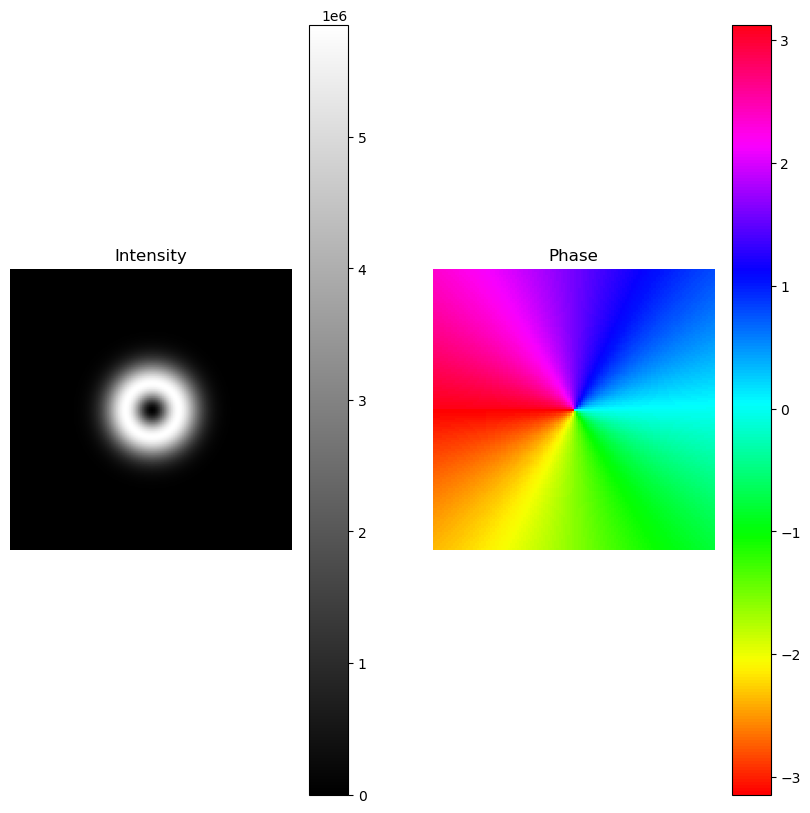

In [28]:
TotInt(list_of_OAMs[1].oamBeam)

Parameters for the genetic algorithm. For ease, we store them in a yaml file. 

In [41]:
import pygad
import yaml 
from yaml import Loader 
import pickle as pkl

num_generations = 100
num_parents_mating =  2

fitness_function = fitness_func 

sol_per_pop = 10 # number of parents in the population?? 
num_genes = 2*len(flattened_phase_1) # This would refer to the number of parameters in our DNA

# Lower and upper-bound ranges of the parameterization. 

init_range_low = -np.pi
init_range_high = np.pi

parent_selection_type = "rank"
#K_tournament = 5 # number of contestants, essentially
#keep_elitism  = 1

crossover_type = "single_point"

mutation_type = "random"
mutation_percent_genes = 10 # probability of mutation 

# This function keeps track of the generation number + best fitness

def on_gen(ga_instance):
    print("Generation : ", ga_instance.generations_completed)
    print("Fitness of the best solution :", ga_instance.best_solution()[1])
    
    solution =  ga_instance.best_solution()[0]
    
    # Checkpoint current best model?
    
    instance_name = 'first_trial'
    
    # Save phase patterns of GA instance itself 
    reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
    reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
    
    phases = np.empty((2,N,N))
    phases[0,:,:] = reshape_phase_1
    phases[1,:,:] = reshape_phase_2
    
    with open(f"best_phases/{instance_name}.pkl", 'wb') as file:
        pkl.dump(phases, file)
    
    ga_instance.save(filename=f'genetic_instances/{instance_name}')
    
    # Save plot every 100 generations 
    
    if (ga_instance.generations_completed % 100 == 0):
        plt.figure()
        plt.plot(ga_instance.best_solutions_fitness)
        plt.savefig(f"plots/fitness_{ga_instance.generations_completed}.jpg")
        plt.show()
        

Create the GA instance

In [42]:
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_function,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=parent_selection_type,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_percent_genes=mutation_percent_genes,
                       on_generation=on_gen)

Now run the GA

In [43]:
import matplotlib.pyplot as plt

ga_instance.run()
ga_instance.plot_fitness()
plt.savefig('plots/figgy.png')

Generation :  1
Fitness of the best solution : -63398.364101613435
Generation :  2
Fitness of the best solution : -63398.364101613435
Generation :  3
Fitness of the best solution : -63398.364101613435
Generation :  4
Fitness of the best solution : -63398.364101613435
Generation :  5
Fitness of the best solution : -63398.364101613435
Generation :  6
Fitness of the best solution : -63398.364101613435
Generation :  7
Fitness of the best solution : -63398.364101613435
Generation :  8
Fitness of the best solution : -63398.364101613435
Generation :  9
Fitness of the best solution : -63398.364101613435
Generation :  10
Fitness of the best solution : -63398.364101613435
Generation :  11
Fitness of the best solution : -63398.364101613435
Generation :  12
Fitness of the best solution : -63398.364101613435
Generation :  13
Fitness of the best solution : -11652.934524872631
Generation :  14
Fitness of the best solution : -11652.934524872631
Generation :  15
Fitness of the best solution : -11652.93

KeyboardInterrupt: 

# Analyzing the Solution of the GA 

extract the solution, and reshape it in an interpretable form 

In [38]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print("Parameters of the best solution : {solution}".format(solution=solution))
print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))


Parameters of the best solution : [-2.56939746  2.16015151 -1.1550802  ... -1.74603473 -2.51820878
  2.6998186 ]
Fitness value of the best solution = -360732.18593133445


Save the genetic instance

In [237]:
instance_name = 'first_trial'
ga_instance.save(filename=f'genetic_instances/{instance_name}')

Let's analyze what we've made

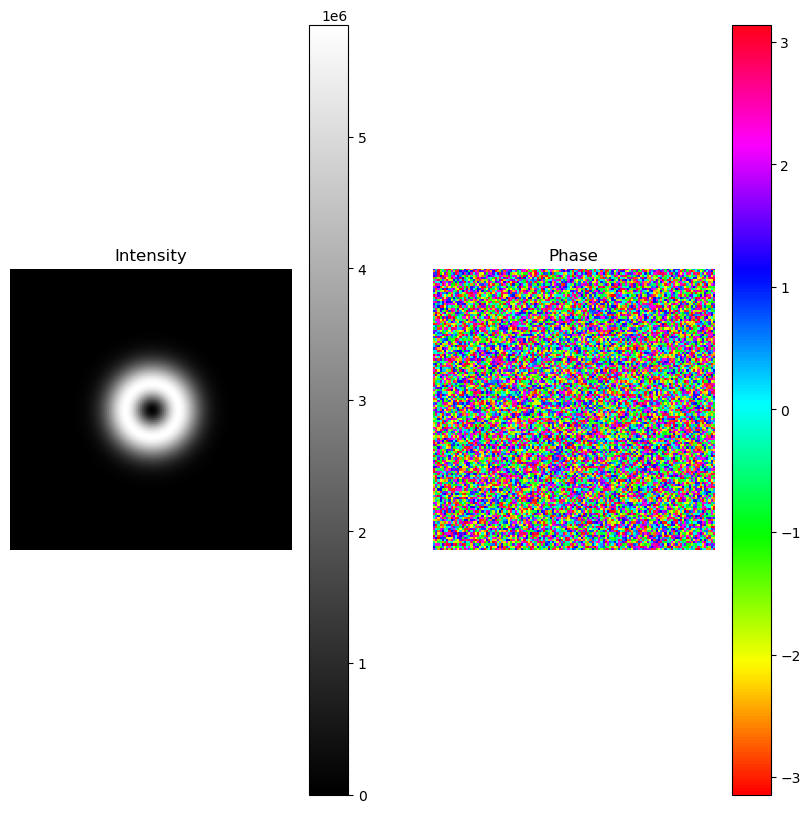

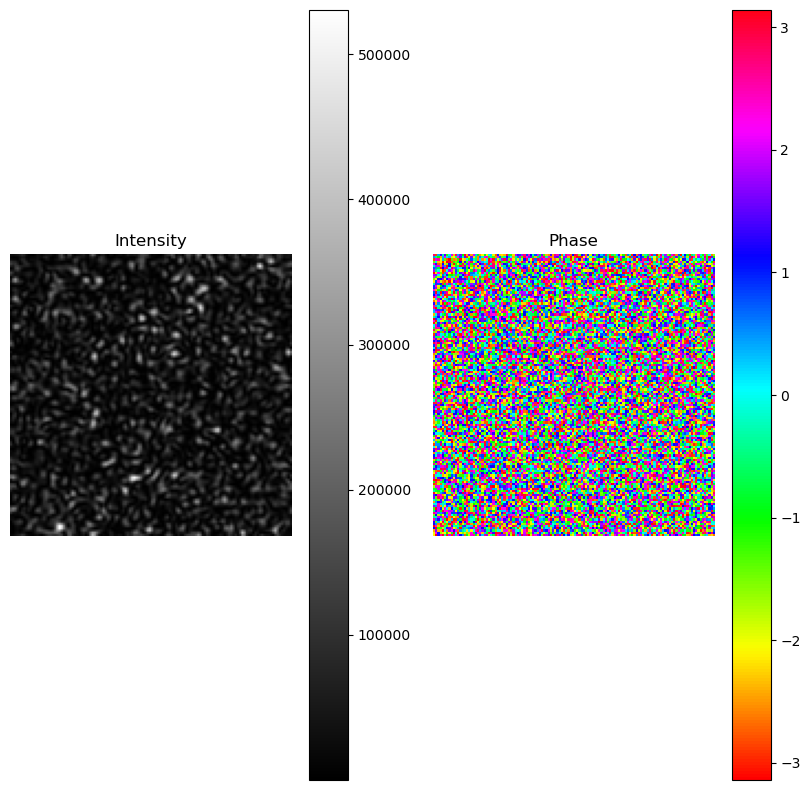

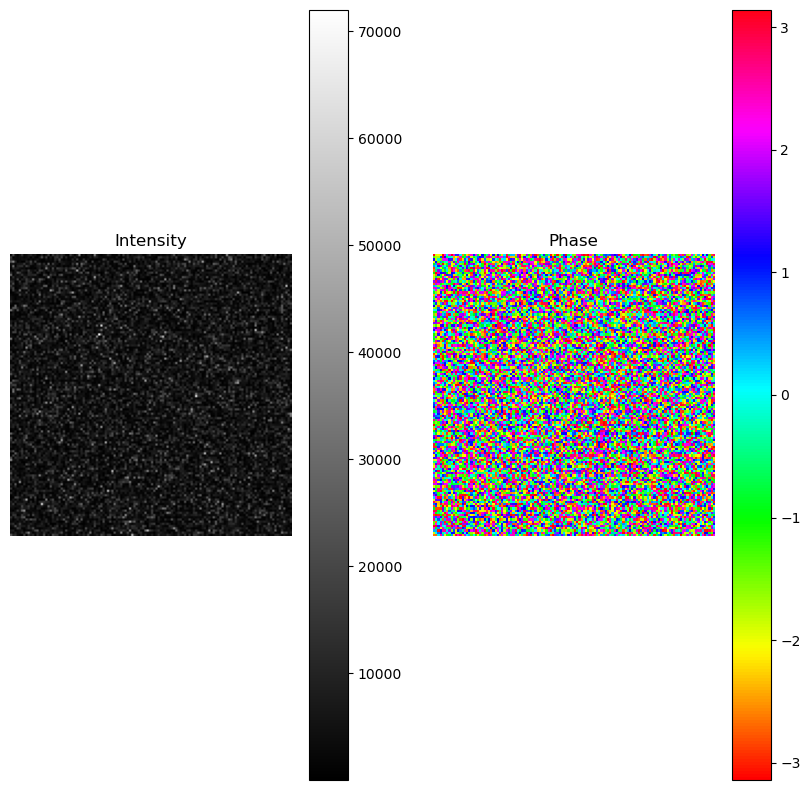

In [39]:
# Let's pick an LG beam to analyze

field = list_of_OAMs[0].oamBeam 

# Create the phase map by reshaping the solution array

reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
phase_map_1 = np.exp(1j*reshape_phase_1)
phase_map_2 = np.exp(1j*reshape_phase_2)

# modulate the field by the first phase map 

field_mod_1 = field*phase_map_1

TotInt(field_mod_1)

# let's simulate the propagation of the lens

field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

# modulate the field by the second phase map 

field_mod_2 = field_lens*phase_map_2

TotInt(field_mod_2)

# simulate the lens field again. This is the final field. 

field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)


TotInt(field_lens_2)

# compute the field intensity 

final_field_int = np.abs(field_lens_2)**2

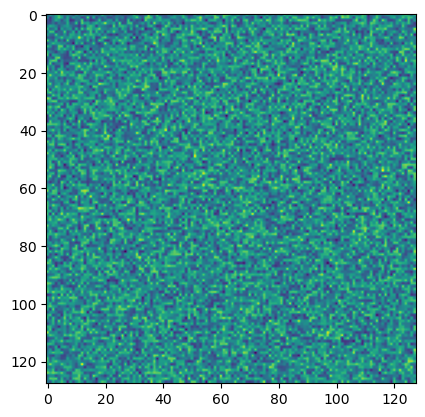

In [40]:
plt.imshow(reshape_phase_1)

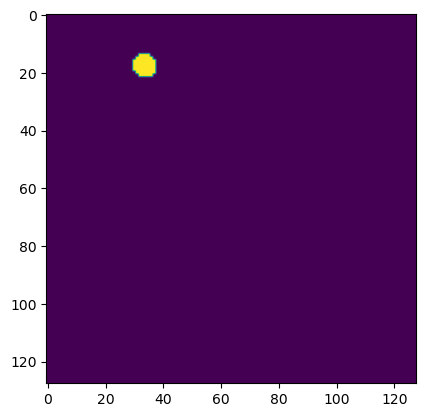

In [223]:

plt.imshow(np.abs(output_chans[1])**2)